# Personalized Health Monitoring Using Machine Learning and LLMs

## Project Overview

This project develops a personalized health monitoring system using wearable sensor data. The objective is to learn an individual's normal physiological behavior, identify unusual heart-rate patterns, group anomalies into meaningful health events, and generate human-readable explanations using a Large Language Model (LLM).

### Project Workflow

1. Load and validate wearable health data
2. Build personalized physiological baselines
3. Engineer behavioral and temporal features
4. Detect anomalies using Isolation Forest
5. Group anomalies into health events
6. Classify event severity
7. Generate AI-powered explanations
8. Produce a health intelligence report

In [238]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

from datetime import datetime
import os
from groq import Groq
# Dark theme plots
plt.style.use('dark_background')


In [239]:
from dotenv import load_dotenv
import os
from groq import Groq

load_dotenv()

client = Groq(
    api_key=os.getenv("GROQ_API_KEY")
)

In [240]:
CONFIG = {

    # Rolling windows
    "SHORT_WINDOW": 12,
    "LONG_WINDOW": 48,

    # Isolation Forest
    "CONTAMINATION": 0.05,
    "RANDOM_STATE": 42,

    # Physiological HR limits
    "MIN_HEART_RATE": 35,
    "MAX_HEART_RATE": 220,

}

In [241]:
import os
import glob

# Find all CSV files in current directory
csv_files = glob.glob("*.csv")

print("📂 Available CSV Files:\n")

for i, file in enumerate(csv_files, start=1):
    print(f"{i}. {file}")

print(f"\n✅ Total CSV files found: {len(csv_files)}")

📂 Available CSV Files:

1. elderly_001.csv
2. adult_001.csv
3. child_001.csv
4. health_events_report.csv

✅ Total CSV files found: 4


In [242]:
# ─────────────────────────────────────────────
#Select & Load Dataset
# ─────────────────────────────────────────────

# Select dataset index from printed list
SELECTED_INDEX = 0   # change this after viewing CSV list

# Get filename
SELECTED_FILE = csv_files[SELECTED_INDEX]

print(f"📌 Selected Dataset: {SELECTED_FILE}")

# Load dataset
df = pd.read_csv(SELECTED_FILE)

print("\n✅ Dataset Loaded Successfully")

# Basic preview
print("\n📊 Dataset Shape:")
print(df.shape)

print("\n📋 First 5 Rows:")
display(df.head())

print("\n🧾 Column Names:")
print(df.columns.tolist())

📌 Selected Dataset: elderly_001.csv

✅ Dataset Loaded Successfully

📊 Dataset Shape:
(2016, 6)

📋 First 5 Rows:


,user_id,timestamp,heart_rate,steps,movement_level,sleep_state
0,elderly_001,2026-05-10 00:00:00,56,0,low,awake
1,elderly_001,2026-05-10 00:05:00,57,0,low,awake
2,elderly_001,2026-05-10 00:10:00,59,0,low,awake
3,elderly_001,2026-05-10 00:15:00,58,0,low,awake
4,elderly_001,2026-05-10 00:20:00,59,0,low,awake



🧾 Column Names:
['user_id', 'timestamp', 'heart_rate', 'steps', 'movement_level', 'sleep_state']


# Data Cleaning

Clean and validate the raw wearable data before feature engineering.

In [243]:
df_clean = df.copy()

print("✅ Working copy created")

✅ Working copy created


In [244]:
df_clean.columns = (
    df_clean.columns
    .str.lower()
    .str.strip()
    .str.replace(" ", "_")
)

print("✅ Column names standardized")

print("\n📋 Columns:")
print(df_clean.columns.tolist())

✅ Column names standardized

📋 Columns:
['user_id', 'timestamp', 'heart_rate', 'steps', 'movement_level', 'sleep_state']


In [245]:
# ─────────────────────────────────────────────
# Remove Invalid Heart Rate Values
# ─────────────────────────────────────────────

if 'heart_rate' in df_clean.columns:

    before_hr = len(df_clean)

    df_clean = df_clean[
        (df_clean['heart_rate'] >= CONFIG["MIN_HEART_RATE"]) &
        (df_clean['heart_rate'] <= CONFIG["MAX_HEART_RATE"])
    ]

    after_hr = len(df_clean)

    print(f"✅ Removed {before_hr - after_hr} invalid HR rows")
    print(f"📊 Remaining rows: {after_hr}")

else:
    print("⚠️ 'heart_rate' column not found")

✅ Removed 0 invalid HR rows
📊 Remaining rows: 2016


In [246]:
# ─────────────────────────────────────────────
# Convert Timestamp Columns
# ─────────────────────────────────────────────

timestamp_cols = ['timestamp', 'datetime', 'date', 'time']

found = False

for col in timestamp_cols:

    if col in df_clean.columns:

        df_clean[col] = pd.to_datetime(df_clean[col])

        print(f"✅ Converted '{col}' to datetime")

        found = True

✅ Converted 'timestamp' to datetime


In [247]:

print("📊 Final Cleaned Dataset Shape:")
print(df_clean.shape)

print("\n📋 Final Columns:")
print(df_clean.columns.tolist())

print("\n🧾 Data Types:")
display(df_clean.dtypes)

print("\n✅ Data Cleaning Completed")

📊 Final Cleaned Dataset Shape:
(2016, 6)

📋 Final Columns:
['user_id', 'timestamp', 'heart_rate', 'steps', 'movement_level', 'sleep_state']

🧾 Data Types:


user_id                   object
timestamp         datetime64[ns]
heart_rate                 int64
steps                      int64
movement_level            object
sleep_state               object
dtype: object


✅ Data Cleaning Completed


# Personalized Baseline Engineering

Create personalized heart-rate baselines and physiological features that represent normal behavior over time.

In [248]:
# ─────────────────────────────────────────────
# Rolling Personalized Heart Rate Baseline
# ─────────────────────────────────────────────

# Rolling heart rate average
df_clean['hr_rolling_avg'] = (
    df_clean['heart_rate']
    .rolling(CONFIG["SHORT_WINDOW"])
    .mean()
)

# Rolling heart rate variability
df_clean['hr_variability'] = (
    df_clean['heart_rate']
    .rolling(CONFIG["SHORT_WINDOW"])
    .std()
)

# Rolling long-term baseline
df_clean['hr_baseline'] = (
    df_clean['heart_rate']
    .rolling(CONFIG["LONG_WINDOW"])
    .median()
)


In [249]:
# ─────────────────────────────────────────────
# Heart Rate Trend Detection
# ─────────────────────────────────────────────

short_trend = (
    df_clean['heart_rate']
    .rolling(CONFIG["SHORT_WINDOW"])
    .mean()
)

long_trend = (
    df_clean['heart_rate']
    .rolling(CONFIG["LONG_WINDOW"])
    .mean()
)

df_clean['trend_delta'] = short_trend - long_trend


In [250]:
# ─────────────────────────────────────────────
# Heart Rate Deviation
# ─────────────────────────────────────────────

df_clean['hr_deviation'] = (
    df_clean['heart_rate'] -
    df_clean['hr_baseline']
)


In [251]:
# ─────────────────────────────────────────────
# Normalized Heart Rate
# ─────────────────────────────────────────────

rolling_std = (
    df_clean['heart_rate']
    .rolling(CONFIG["LONG_WINDOW"])
    .std()
)

df_clean['normalized_hr'] = (
    (
        df_clean['heart_rate'] -
        df_clean['hr_baseline']
    )
    /
    (rolling_std + 1e-5)
)


In [252]:
# ─────────────────────────────────────────────
# Handle Rolling NaN Values
# ─────────────────────────────────────────────

rolling_cols = [
    'hr_rolling_avg',
    'hr_variability',
    'hr_baseline',
    'trend_delta',
    'hr_deviation',
    'normalized_hr'
]

df_clean[rolling_cols] = (
    df_clean[rolling_cols]
    .bfill()
)

# Behavioral Feature Engineering

Generate activity and sleep-related features to provide behavioral context for health monitoring.

In [253]:
# Default activity mapping
# low = 0
# medium = 1
# high = 2

if 'steps' in df_clean.columns:

    df_clean['activity_level'] = pd.cut(
        df_clean['steps'],
        bins=[-1, 20, 100, np.inf],
        labels=[0, 1, 2]
    ).astype(int)


else:
    df_clean['activity_level'] = 0

In [254]:
if 'sleep_hours' in df_clean.columns:

    df_clean['is_asleep'] = (
        df_clean['sleep_hours'] > 0
    ).astype(int)
else:
    df_clean['is_asleep'] = 0

In [255]:
if 'steps' in df_clean.columns:

    df_clean['step_rate'] = (
        df_clean['steps'] / 5
    )
else:
    df_clean['step_rate'] = 0


# Exploratory Data Analysis

Explore heart-rate patterns, trends, variability, and feature relationships.

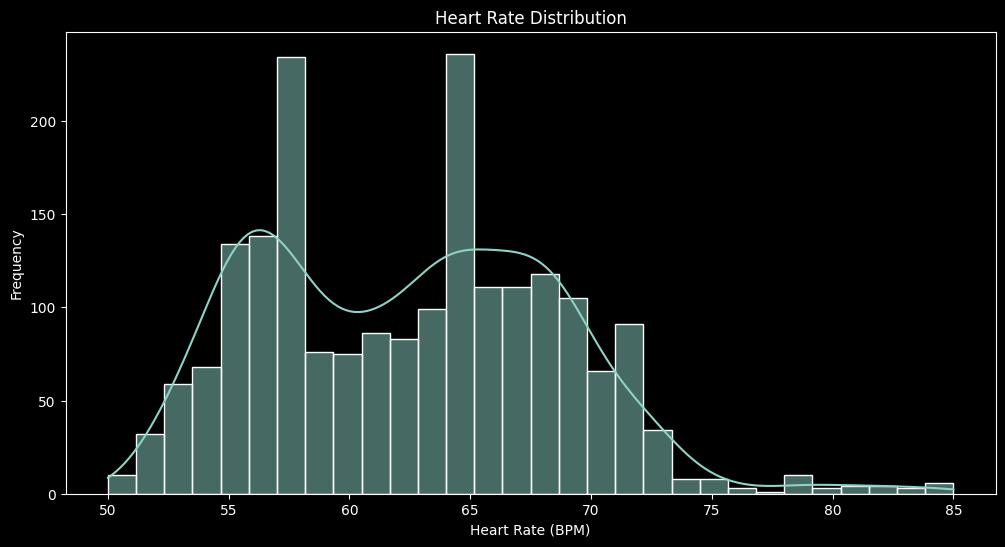

In [256]:
# ─────────────────────────────────────────────
# Heart Rate Distribution
# ─────────────────────────────────────────────

plt.figure(figsize=(12,6))

sns.histplot(
    df_clean['heart_rate'],
    bins=30,
    kde=True
)

plt.title("Heart Rate Distribution")
plt.xlabel("Heart Rate (BPM)")
plt.ylabel("Frequency")

plt.show()

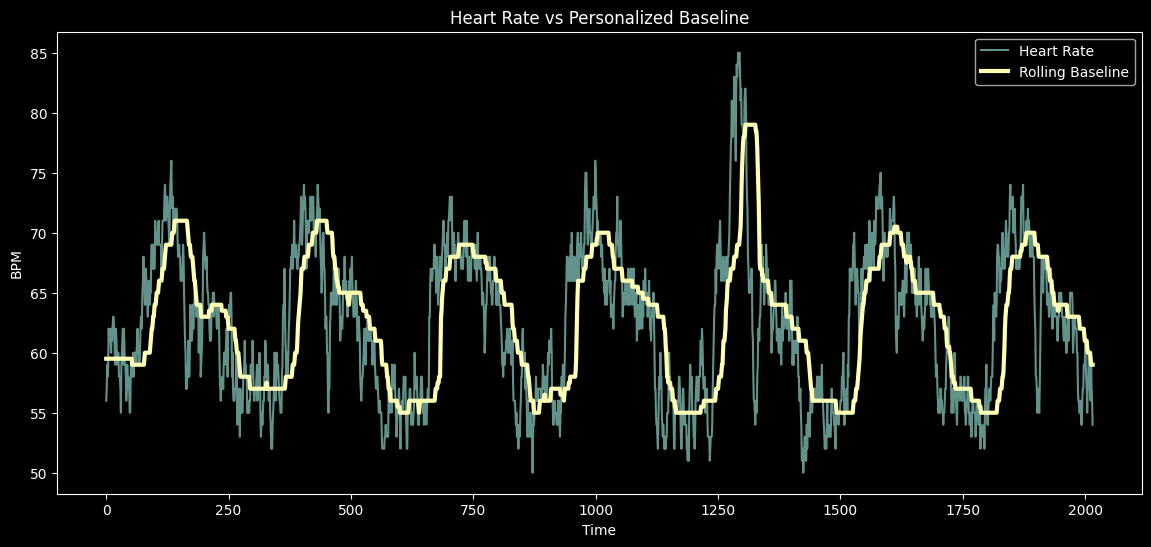

In [257]:
# ─────────────────────────────────────────────
# HR vs Personal Baseline
# ─────────────────────────────────────────────

plt.figure(figsize=(14,6))

plt.plot(
    df_clean['heart_rate'],
    label='Heart Rate',
    alpha=0.7
)

plt.plot(
    df_clean['hr_baseline'],
    label='Rolling Baseline',
    linewidth=3
)

plt.title("Heart Rate vs Personalized Baseline")

plt.xlabel("Time")

plt.ylabel("BPM")

plt.legend()

plt.show()

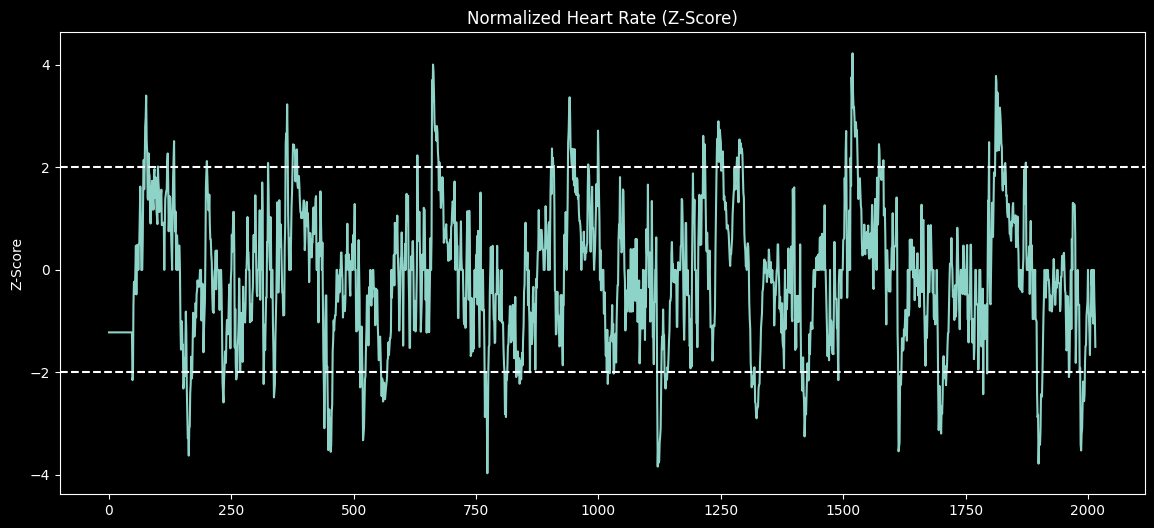

In [258]:
# ─────────────────────────────────────────────
# Normalized HR Trend
# ─────────────────────────────────────────────

plt.figure(figsize=(14,6))

plt.plot(
    df_clean['normalized_hr']
)

plt.axhline(2, linestyle='--')
plt.axhline(-2, linestyle='--')

plt.title("Normalized Heart Rate (Z-Score)")
plt.ylabel("Z-Score")

plt.show()

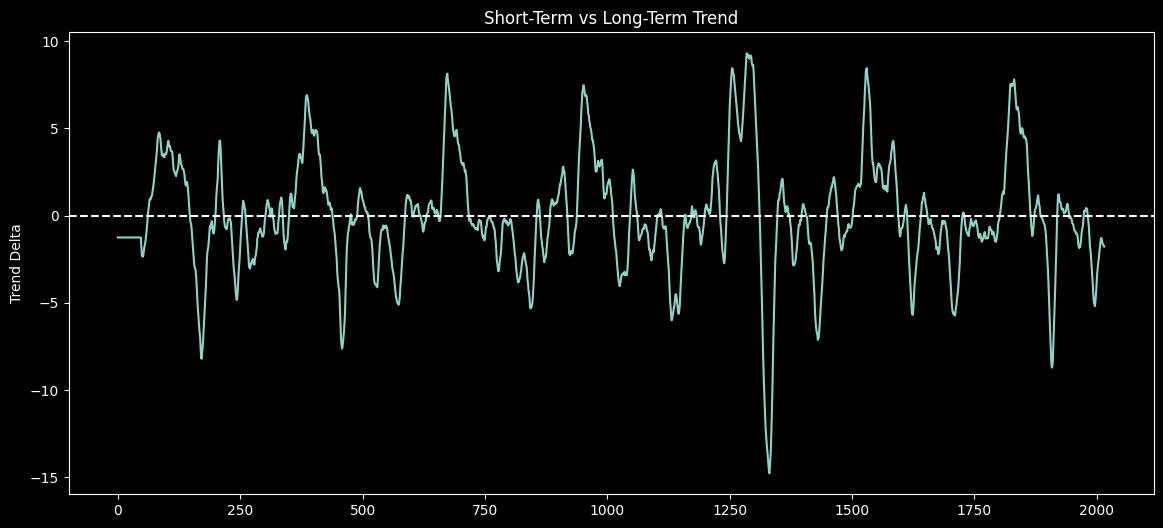

In [259]:
# ─────────────────────────────────────────────
# Trend Delta
# ─────────────────────────────────────────────

plt.figure(figsize=(14,6))

plt.plot(
    df_clean['trend_delta']
)

plt.axhline(0, linestyle='--')

plt.title("Short-Term vs Long-Term Trend")
plt.ylabel("Trend Delta")

plt.show()

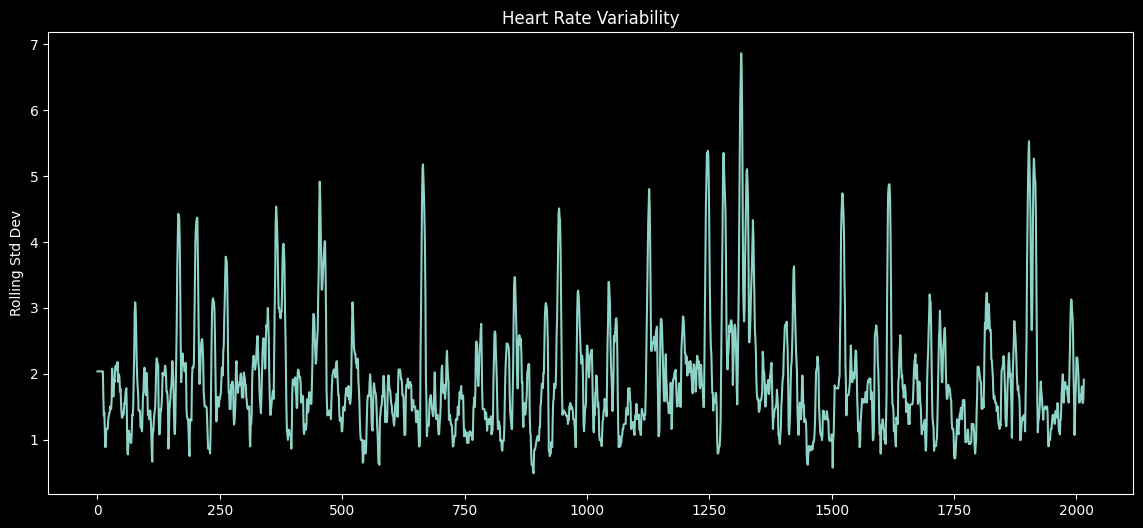

In [260]:
# ─────────────────────────────────────────────
# Heart Rate Variability Trend
# ─────────────────────────────────────────────

plt.figure(figsize=(14,6))

plt.plot(
    df_clean['hr_variability']
)

plt.title("Heart Rate Variability")
plt.ylabel("Rolling Std Dev")

plt.show()

In [261]:
# ─────────────────────────────────────────────
# Feature List
# ─────────────────────────────────────────────

FEATURE_COLS = [
    'heart_rate',
    'normalized_hr',
    'hr_deviation',
    'hr_rolling_avg',
    'hr_variability',
    'trend_delta'
]

print("✅ Feature list created")

✅ Feature list created


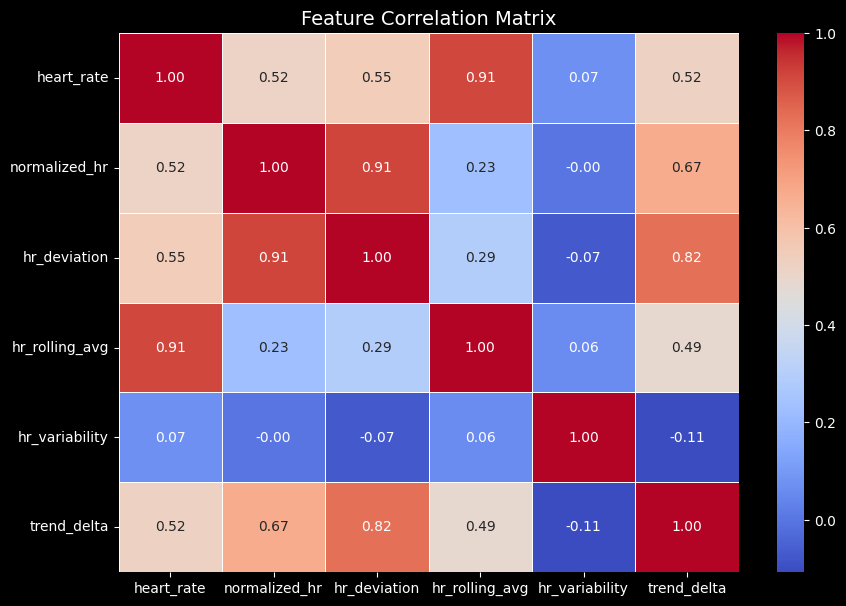

In [262]:
# ─────────────────────────────────────────────
# Feature Correlation Matrix
# ─────────────────────────────────────────────

corr_matrix = (
    df_clean[FEATURE_COLS]
    .corr()
)

plt.figure(figsize=(10, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Feature Correlation Matrix", fontsize=14)

plt.show()

# Machine Learning Pipeline

Train an Isolation Forest model to identify unusual physiological behavior.

In [263]:
# ─────────────────────────────────────────────
# Prepare Features
# ─────────────────────────────────────────────

X = df_clean[FEATURE_COLS].copy()

print("Feature Matrix Shape:")
print(X.shape)

display(X.head())

Feature Matrix Shape:
(2016, 6)


,heart_rate,normalized_hr,hr_deviation,hr_rolling_avg,hr_variability,trend_delta
0,56,-1.219046,-2.5,59.833333,2.037527,-1.25
1,57,-1.219046,-2.5,59.833333,2.037527,-1.25
2,59,-1.219046,-2.5,59.833333,2.037527,-1.25
3,58,-1.219046,-2.5,59.833333,2.037527,-1.25
4,59,-1.219046,-2.5,59.833333,2.037527,-1.25


In [264]:
# ─────────────────────────────────────────────
# Feature Scaling
# ─────────────────────────────────────────────

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(2016, 6)


In [265]:
# ─────────────────────────────────────────────
# Isolation Forest
# ─────────────────────────────────────────────

iso_model = IsolationForest(
    n_estimators=200,
    contamination=CONFIG["CONTAMINATION"],
    random_state=CONFIG["RANDOM_STATE"]
)

iso_model.fit(X_scaled)


IsolationForest(contamination=0.05, n_estimators=200, random_state=42)

In [266]:
# ─────────────────────────────────────────────
# Generate Anomaly Predictions
# ─────────────────────────────────────────────

df_clean['if_prediction'] = iso_model.predict(X_scaled)

df_clean['if_anomaly'] = (
    df_clean['if_prediction'] == -1
).astype(int)

print("\nAnomaly Counts:")

print(df_clean['if_anomaly'].value_counts())


Anomaly Counts:
if_anomaly
0    1915
1     101
Name: count, dtype: int64


In [267]:
# ─────────────────────────────────────────────
# Anomaly Score
# ─────────────────────────────────────────────

df_clean['if_score'] = (
    -iso_model.decision_function(X_scaled)
)


df_clean[['if_anomaly','if_score']].head()

,if_anomaly,if_score
0,0,-0.168209
1,0,-0.171208
2,0,-0.177358
3,0,-0.174130
4,0,-0.177358


In [268]:
# ─────────────────────────────────────────────
# Model Validation
# ─────────────────────────────────────────────

anomaly_rate = (
    df_clean['if_anomaly']
    .mean()
    * 100
)

print(f"Anomaly Rate: {anomaly_rate:.2f}%")

print(
    f"Total Anomalies: "
    f"{df_clean['if_anomaly'].sum()}"
)

Anomaly Rate: 5.01%
Total Anomalies: 101


# Severity Classification

Categorize detected anomalies based on anomaly score intensity.

In [269]:
# ─────────────────────────────────────────────
# Severity Thresholds
# ─────────────────────────────────────────────

medium_thr = df_clean['if_score'].quantile(0.75)
high_thr = df_clean['if_score'].quantile(0.90)
critical_thr = df_clean['if_score'].quantile(0.98)

print(f"Medium   : {medium_thr:.3f}")
print(f"High     : {high_thr:.3f}")
print(f"Critical : {critical_thr:.3f}")

Medium   : -0.108
High     : -0.052
Critical : 0.048


In [270]:
# ─────────────────────────────────────────────
# Severity Labels
# ─────────────────────────────────────────────

def label_severity(score):

    if score >= critical_thr:
        return "Critical"

    elif score >= high_thr:
        return "High"

    elif score >= medium_thr:
        return "Medium"

    return "Normal"


df_clean['severity'] = (
    df_clean['if_score']
    .apply(label_severity)
)

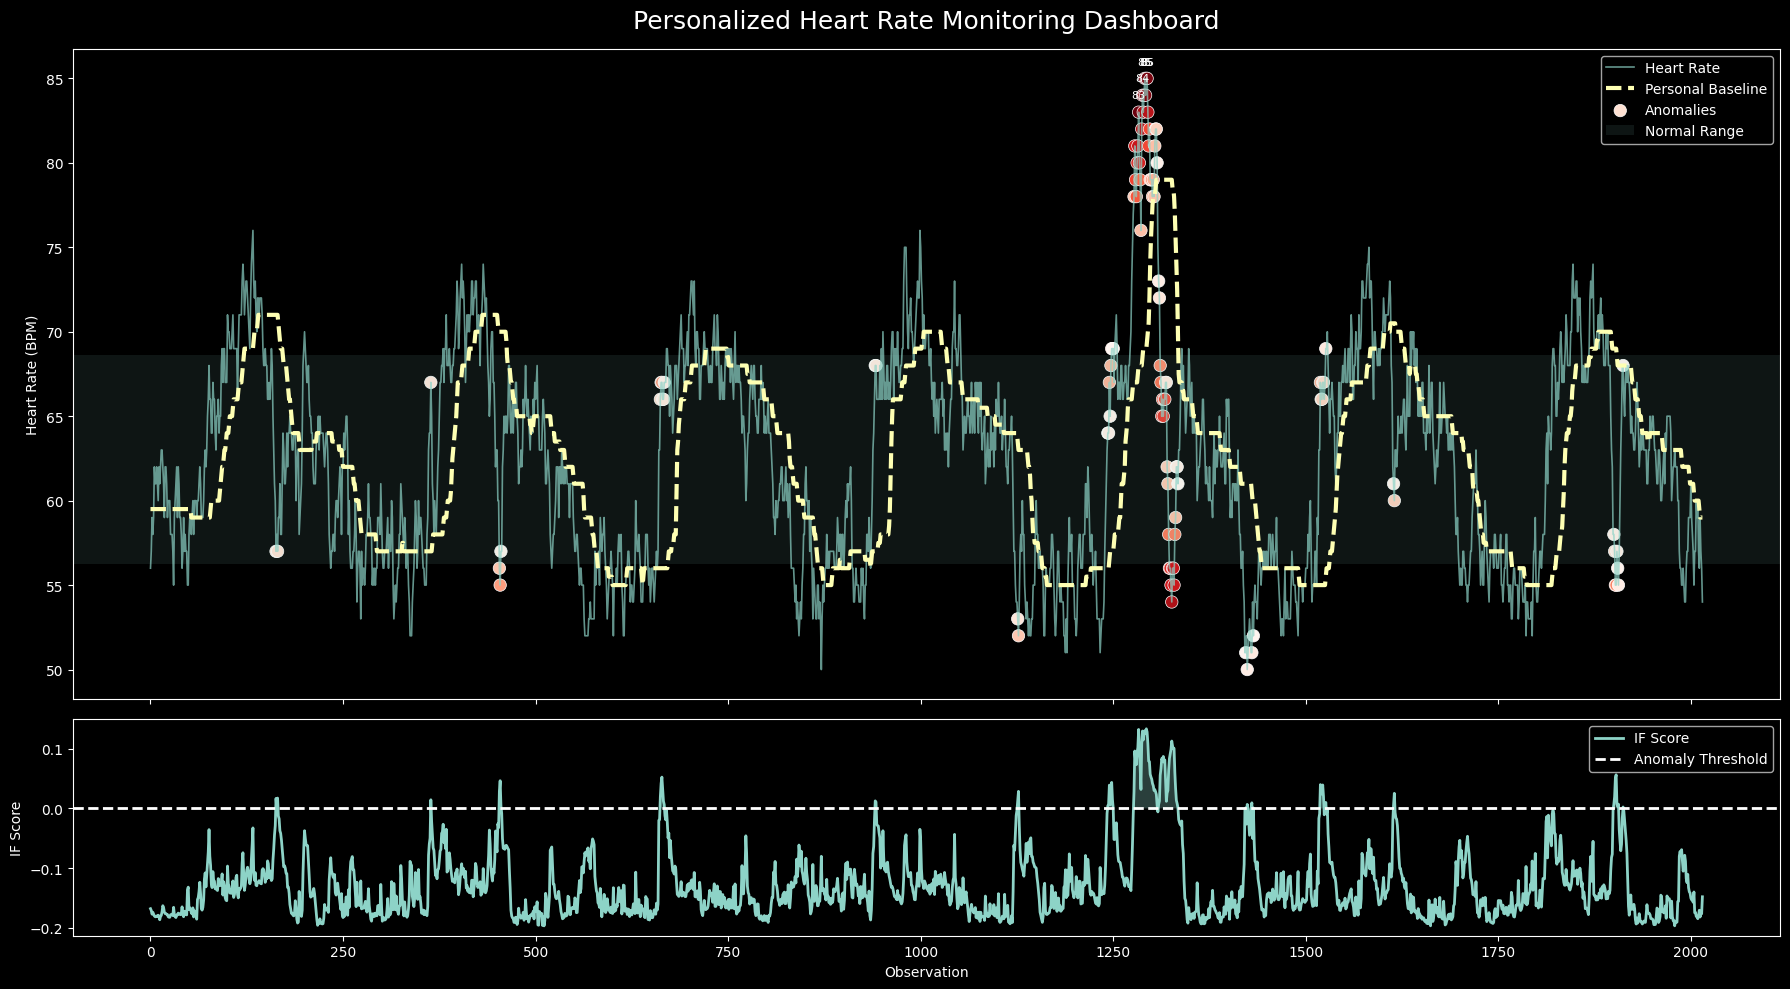

In [271]:
# ─────────────────────────────────────────────
# HEALTH MONITORING DASHBOARD
# ─────────────────────────────────────────────

fig, (ax1, ax2) = plt.subplots(
    2,
    1,
    figsize=(18, 10),
    sharex=True,
    gridspec_kw={'height_ratios': [3, 1]}
)

# =========================
# TOP PANEL
# =========================

ax1.plot(
    df_clean.index,
    df_clean['heart_rate'],
    linewidth=1.2,
    alpha=0.7,
    label='Heart Rate'
)

ax1.plot(
    df_clean.index,
    df_clean['hr_baseline'],
    linewidth=3,
    linestyle='--',
    label='Personal Baseline'
)

# anomalies only
anoms = df_clean[df_clean['if_anomaly'] == 1]

scatter = ax1.scatter(
    anoms.index,
    anoms['heart_rate'],
    c=anoms['if_score'],
    cmap='Reds',
    s=80,
    edgecolors='white',
    linewidths=0.5,
    label='Anomalies'
)

# normal HR zone
mean_hr = df_clean['heart_rate'].mean()
std_hr = df_clean['heart_rate'].std()

ax1.axhspan(
    mean_hr - std_hr,
    mean_hr + std_hr,
    alpha=0.1,
    label='Normal Range'
)

ax1.set_title(
    "Personalized Heart Rate Monitoring Dashboard",
    fontsize=18,
    pad=15
)

ax1.set_ylabel("Heart Rate (BPM)")
ax1.legend(loc='upper right')

# annotate top 5 events
top_events = (
    anoms
    .sort_values('if_score', ascending=False)
    .head(5)
)

for idx, row in top_events.iterrows():

    ax1.annotate(
        f"{row['heart_rate']:.0f}",
        xy=(idx, row['heart_rate']),
        xytext=(0, 10),
        textcoords='offset points',
        ha='center',
        fontsize=8
    )

# =========================
# BOTTOM PANEL
# =========================

ax2.plot(
    df_clean.index,
    df_clean['if_score'],
    linewidth=2,
    label='IF Score'
)

threshold = np.percentile(
    df_clean['if_score'],
    95
)

ax2.axhline(
    threshold,
    linestyle='--',
    linewidth=2,
    label='Anomaly Threshold'
)

ax2.fill_between(
    df_clean.index,
    threshold,
    df_clean['if_score'],
    where=df_clean['if_score'] > threshold,
    alpha=0.3
)

ax2.set_ylabel("IF Score")
ax2.set_xlabel("Observation")
ax2.legend()

plt.tight_layout()
plt.show()

Baseline Statistics

In [272]:
# ─────────────────────────────────────────────
# Personal Baseline Summary
# ─────────────────────────────────────────────

baseline = {
    "avg_hr": df_clean['heart_rate'].mean(),
    "std_hr": df_clean['heart_rate'].std(),
    "avg_hrv": df_clean['hr_variability'].mean()
}

baseline

{'avg_hr': np.float64(62.45436507936508),
 'std_hr': np.float64(6.188992132530696),
 'avg_hrv': np.float64(1.9105060685491475)}

# Event Detection Engine

Group anomaly points into meaningful health events for further analysis.

In [273]:
# ─────────────────────────────────────────────
# Event Detection
# ─────────────────────────────────────────────

# Identify start of new anomaly events
df_clean['event_start'] = (
    df_clean['if_anomaly']
    .ne(df_clean['if_anomaly'].shift())
)

# Assign event groups
df_clean['event_group'] = (
    df_clean['event_start']
    .cumsum()
)

# Keep anomaly groups only
event_df = df_clean[df_clean['if_anomaly'] == 1].copy()

print(f"Total Anomaly Rows: {len(event_df)}")

Total Anomaly Rows: 101


In [274]:
# ─────────────────────────────────────────────
# Event Summary Table
# ─────────────────────────────────────────────

events = (
    event_df
    .groupby('event_group')
    .agg(
        start_idx=('heart_rate', lambda x: x.index.min()),
        end_idx=('heart_rate', lambda x: x.index.max()),
        duration=('heart_rate', 'count'),
        peak_hr=('heart_rate', 'max'),
        mean_hr=('heart_rate', 'mean'),
        peak_score=('if_score', 'max')
    )
    .reset_index(drop=True)
)

print(f"Detected Events: {len(events)}")

display(events.head())

Detected Events: 19


,start_idx,end_idx,duration,peak_hr,mean_hr,peak_score
0,163,163,1,57,57.0,0.016777
1,165,165,1,57,57.0,0.017279
2,364,364,1,67,67.0,0.014415
3,453,455,3,57,56.0,0.046402
4,662,667,6,67,66.5,0.052457


In [275]:
# ─────────────────────────────────────────────
# Event Tagging
# ─────────────────────────────────────────────

baseline_hr = baseline['avg_hr']

def classify_event(row):

    increase_pct = (
        (row['peak_hr'] - baseline_hr)
        / baseline_hr
    ) * 100

    if increase_pct > 25:
        return "Elevated HR Episode"

    elif row['duration'] > 10:
        return "Persistent HR Elevation"

    elif row['peak_hr'] < baseline_hr * 0.8:
        return "Low HR Event"

    else:
        return "Transient HR Anomaly"

events['event_type'] = (
    events
    .apply(classify_event, axis=1)
)

display(events)

,start_idx,end_idx,duration,peak_hr,mean_hr,peak_score,event_type
0,163,163,1,57,57.000000,0.016777,Transient HR Anomaly
1,165,165,1,57,57.000000,0.017279,Transient HR Anomaly
2,364,364,1,67,67.000000,0.014415,Transient HR Anomaly
3,453,455,3,57,56.000000,0.046402,Transient HR Anomaly
4,662,667,6,67,66.500000,0.052457,Transient HR Anomaly
5,941,942,2,68,68.000000,0.012560,Transient HR Anomaly
6,1126,1127,2,53,52.500000,0.028550,Transient HR Anomaly
7,1243,1250,8,69,66.875000,0.043556,Transient HR Anomaly
8,1277,1307,31,85,80.967742,0.133436,Elevated HR Episode
9,1309,1334,26,73,62.038462,0.112915,Persistent HR Elevation


In [276]:
events['duration_minutes'] = (
    events['duration'] * 5
)

In [277]:
# ─────────────────────────────────────────────
# Event Enrichment
# ─────────────────────────────────────────────

events['event_id'] = [
    f"EVT_{i:03d}"
    for i in range(1, len(events)+1)
]

events['baseline_hr'] = baseline['avg_hr']

events['hr_increase_pct'] = (
    (
        events['peak_hr']
        - events['baseline_hr']
    )
    /
    events['baseline_hr']
) * 100

events['is_short_event'] = (
    events['duration'] < 3
)

display(events.head(20))

,start_idx,end_idx,duration,peak_hr,mean_hr,peak_score,event_type,duration_minutes,event_id,baseline_hr,hr_increase_pct,is_short_event
0,163,163,1,57,57.000000,0.016777,Transient HR Anomaly,5,EVT_001,62.454365,-8.733361,True
1,165,165,1,57,57.000000,0.017279,Transient HR Anomaly,5,EVT_002,62.454365,-8.733361,True
2,364,364,1,67,67.000000,0.014415,Transient HR Anomaly,5,EVT_003,62.454365,7.278330,True
3,453,455,3,57,56.000000,0.046402,Transient HR Anomaly,15,EVT_004,62.454365,-8.733361,False
4,662,667,6,67,66.500000,0.052457,Transient HR Anomaly,30,EVT_005,62.454365,7.278330,False
5,941,942,2,68,68.000000,0.012560,Transient HR Anomaly,10,EVT_006,62.454365,8.879499,True
6,1126,1127,2,53,52.500000,0.028550,Transient HR Anomaly,10,EVT_007,62.454365,-15.138037,True
7,1243,1250,8,69,66.875000,0.043556,Transient HR Anomaly,40,EVT_008,62.454365,10.480668,False
8,1277,1307,31,85,80.967742,0.133436,Elevated HR Episode,155,EVT_009,62.454365,36.099374,False
9,1309,1334,26,73,62.038462,0.112915,Persistent HR Elevation,130,EVT_010,62.454365,16.885345,False


In [278]:
# ─────────────────────────────────────────────
# Event Severity
# ─────────────────────────────────────────────

event_high = events['peak_score'].quantile(0.90)
event_critical = events['peak_score'].quantile(0.98)

def classify_event_severity(score):

    if score >= event_critical:
        return "Critical"

    elif score >= event_high:
        return "High"

    return "Medium"

events['severity'] = (
    events['peak_score']
    .apply(classify_event_severity)
)

display(
    events[
        [
            'event_id',
            'peak_score',
            'severity'
        ]
    ].head(20)
)

,event_id,peak_score,severity
0,EVT_001,0.016777,Medium
1,EVT_002,0.017279,Medium
2,EVT_003,0.014415,Medium
3,EVT_004,0.046402,Medium
4,EVT_005,0.052457,Medium
5,EVT_006,0.012560,Medium
6,EVT_007,0.028550,Medium
7,EVT_008,0.043556,Medium
8,EVT_009,0.133436,Critical
9,EVT_010,0.112915,High


In [279]:
# ─────────────────────────────────────────────
# Event Ranking
# ─────────────────────────────────────────────

events['event_rank'] = (
    events['peak_score']
    .rank(
        ascending=False,
        method='dense'
    )
    .astype(int)
)

display(
    events.sort_values(
        'event_rank'
    ).head(10)
)

,start_idx,end_idx,duration,peak_hr,mean_hr,peak_score,event_type,duration_minutes,event_id,baseline_hr,hr_increase_pct,is_short_event,severity,event_rank
8,1277,1307,31,85,80.967742,0.133436,Elevated HR Episode,155,EVT_009,62.454365,36.099374,False,Critical,1
9,1309,1334,26,73,62.038462,0.112915,Persistent HR Elevation,130,EVT_010,62.454365,16.885345,False,High,2
17,1900,1906,7,58,56.142857,0.056328,Transient HR Anomaly,35,EVT_018,62.454365,-7.132192,False,Medium,3
4,662,667,6,67,66.500000,0.052457,Transient HR Anomaly,30,EVT_005,62.454365,7.278330,False,Medium,4
3,453,455,3,57,56.000000,0.046402,Transient HR Anomaly,15,EVT_004,62.454365,-8.733361,False,Medium,5
7,1243,1250,8,69,66.875000,0.043556,Transient HR Anomaly,40,EVT_008,62.454365,10.480668,False,Medium,6
14,1519,1523,5,67,66.600000,0.039870,Transient HR Anomaly,25,EVT_015,62.454365,7.278330,False,Medium,7
6,1126,1127,2,53,52.500000,0.028550,Transient HR Anomaly,10,EVT_007,62.454365,-15.138037,True,Medium,8
16,1614,1615,2,61,60.500000,0.025263,Transient HR Anomaly,10,EVT_017,62.454365,-2.328684,True,Medium,9
1,165,165,1,57,57.000000,0.017279,Transient HR Anomaly,5,EVT_002,62.454365,-8.733361,True,Medium,10


LLM integration 

In [280]:
# ─────────────────────────────────────────────
# LLM Context Builder
# ─────────────────────────────────────────────

events['llm_context'] = events.apply(
    lambda row: f"""
Event ID: {row['event_id']}
Event Type: {row['event_type']}
Severity: {row['severity']}
Duration: {row['duration_minutes']} minutes
Peak HR: {row['peak_hr']:.1f} bpm
Mean HR: {row['mean_hr']:.1f} bpm
Baseline HR: {row['baseline_hr']:.1f} bpm
Increase Above Baseline: {row['hr_increase_pct']:.1f}%

Explain this event in simple language.
Suggest possible physiological reasons.
Do not make medical diagnoses.
""",
    axis=1
)

display(
    events[
        [
            'event_id',
            'event_type',
            'severity',
            'llm_context'
        ]
    ].head(3)
)

,event_id,event_type,severity,llm_context
0,EVT_001,Transient HR Anomaly,Medium,\nEvent ID: EVT_001\nEvent Type: Transient HR ...
1,EVT_002,Transient HR Anomaly,Medium,\nEvent ID: EVT_002\nEvent Type: Transient HR ...
2,EVT_003,Transient HR Anomaly,Medium,\nEvent ID: EVT_003\nEvent Type: Transient HR ...


In [281]:
# ─────────────────────────────────────────────
# Final Event Dataset
# ─────────────────────────────────────────────

final_events = events[
    [
        'event_id',
        'start_idx',
        'end_idx',
        'duration',
        'duration_minutes',
        'peak_hr',
        'mean_hr',
        'baseline_hr',
        'hr_increase_pct',
        'peak_score',
        'severity',
        'event_rank',
        'event_type',
        'is_short_event',
        'llm_context'
    ]
].copy()

print(f"Total Events: {len(final_events)}")

display(final_events.head())

Total Events: 19


,event_id,start_idx,end_idx,duration,duration_minutes,peak_hr,mean_hr,baseline_hr,hr_increase_pct,peak_score,severity,event_rank,event_type,is_short_event,llm_context
0,EVT_001,163,163,1,5,57,57.0,62.454365,-8.733361,0.016777,Medium,11,Transient HR Anomaly,True,\nEvent ID: EVT_001\nEvent Type: Transient HR ...
1,EVT_002,165,165,1,5,57,57.0,62.454365,-8.733361,0.017279,Medium,10,Transient HR Anomaly,True,\nEvent ID: EVT_002\nEvent Type: Transient HR ...
2,EVT_003,364,364,1,5,67,67.0,62.454365,7.278330,0.014415,Medium,12,Transient HR Anomaly,True,\nEvent ID: EVT_003\nEvent Type: Transient HR ...
3,EVT_004,453,455,3,15,57,56.0,62.454365,-8.733361,0.046402,Medium,5,Transient HR Anomaly,False,\nEvent ID: EVT_004\nEvent Type: Transient HR ...
4,EVT_005,662,667,6,30,67,66.5,62.454365,7.278330,0.052457,Medium,4,Transient HR Anomaly,False,\nEvent ID: EVT_005\nEvent Type: Transient HR ...


In [282]:
# ─────────────────────────────────────────────
# Health Summary
# ─────────────────────────────────────────────

print("\n" + "="*60)
print("PERSONAL HEALTH SUMMARY")
print("="*60)

print(f"Average Heart Rate : {baseline['avg_hr']:.1f} bpm")
print(f"HR Variability     : {baseline['std_hr']:.1f} bpm")
print(f"Anomaly Rate       : {anomaly_rate:.2f}%")
print(f"Total Events       : {len(final_events)}")

print("\nEvent Types:")

print(
    final_events['event_type']
    .value_counts()
)

print("="*60)


PERSONAL HEALTH SUMMARY
Average Heart Rate : 62.5 bpm
HR Variability     : 6.2 bpm
Anomaly Rate       : 5.01%
Total Events       : 19

Event Types:
event_type
Transient HR Anomaly       17
Elevated HR Episode         1
Persistent HR Elevation     1
Name: count, dtype: int64


# LLM-Powered Event Interpretation

Generate human-readable explanations for detected health events using a Large Language Model.

In [283]:
# ─────────────────────────────────────────────
# LLM Event Explanations
# ─────────────────────────────────────────────

def generate_explanation(context):

    prompt = f"""
You are a wearable health analytics assistant.

Analyze the event below.

{context}

Instructions:
1. Explain what happened.
2. Explain why it is unusual.
3. Provide possible non-medical explanations.
4. Explain the significance.
5. Do not diagnose diseases.
6. Keep response under 150 words.
"""

    response = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ],
        temperature=0.3
    )

    return (
        response
        .choices[0]
        .message
        .content
    )

In [284]:
# ─────────────────────────────────────────────
# Generate LLM Explanations For All Events
# ─────────────────────────────────────────────

events['llm_explanation'] = (
    events['llm_context']
    .apply(generate_explanation)
)

print("✅ LLM explanations generated")

display(
    events[
        [
            'event_id',
            'event_type',
            'severity',
            'llm_explanation'
        ]
    ].head()
)

✅ LLM explanations generated


,event_id,event_type,severity,llm_explanation
0,EVT_001,Transient HR Anomaly,Medium,"A transient heart rate anomaly occurred, lasti..."
1,EVT_002,Transient HR Anomaly,Medium,"A transient heart rate anomaly occurred, lasti..."
2,EVT_003,Transient HR Anomaly,Medium,"A transient heart rate anomaly occurred, lasti..."
3,EVT_004,Transient HR Anomaly,Medium,"A transient heart rate anomaly occurred, lasti..."
4,EVT_005,Transient HR Anomaly,Medium,A 30-minute anomaly in heart rate (HR) was det...


In [285]:
final_events = events[
    [
        'event_id',
        'event_type',
        'severity',
        'duration_minutes',
        'peak_hr',
        'baseline_hr',
        'hr_increase_pct',
        'peak_score',
        'llm_explanation'
    ]
].copy()

display(final_events.head())

,event_id,event_type,severity,duration_minutes,peak_hr,baseline_hr,hr_increase_pct,peak_score,llm_explanation
0,EVT_001,Transient HR Anomaly,Medium,5,57,62.454365,-8.733361,0.016777,"A transient heart rate anomaly occurred, lasti..."
1,EVT_002,Transient HR Anomaly,Medium,5,57,62.454365,-8.733361,0.017279,"A transient heart rate anomaly occurred, lasti..."
2,EVT_003,Transient HR Anomaly,Medium,5,67,62.454365,7.278330,0.014415,"A transient heart rate anomaly occurred, lasti..."
3,EVT_004,Transient HR Anomaly,Medium,15,57,62.454365,-8.733361,0.046402,"A transient heart rate anomaly occurred, lasti..."
4,EVT_005,Transient HR Anomaly,Medium,30,67,62.454365,7.278330,0.052457,A 30-minute anomaly in heart rate (HR) was det...


# Health Intelligence Report

Compile detected events, severity levels, and AI-generated explanations into a final report.

In [286]:
final_events.to_csv(
    "health_events_report.csv",
    index=False
)

print("✅ Health Event Report Generated")

✅ Health Event Report Generated
